## **Assignment - Introdução à Ciência de Dados**


#### **Business understanding**


Before launching a new food product to the market, companies typically rely on sensory panels to evaluate consumer appreciation relying on different topics such as taste, texture, aroma, and overall quality. Product success in the market does not depend solely on sensory perception, but is also influenced by external factors such as branding and marketing investment. As a result, companies face uncertaintywhen deciding whether a new product should proceed to market.

The business problem addressed in this project is to assess whether data-driven models can help reduce this uncertainty by predicting product appreciation and market success before a product is launched. Specifically, the company seeks to understand whether it is possible to estimate the overall appreciation score and to predict whether a product will be successful in the market, based on a combination of product characteristics, sensory attributes, and external factors. If successful, such models could support decision-making processes, reduce development costs, and potentially decrease the reliance on extensive sensory testing.

From a data science perspective, this business objective can be divided into two predictive tasks. The first task is a regression problem, where the goal is to predict the numerical variable representing overall appreciation. The second task is a classification problem, where the objective is to predict a binary outcome indicating whether a product would be successful in the market.

The models should achieve predictive accuracy on unseen data, demonstrating the ability to generalize beyond the products observed during training. Ultimately, the value of this analysis lies not only in building accurate predictive models, but also in supporting informed decisions about product development, testing strategies, and market launch risk.

#### **Data understanding**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_excel("/Users/raque/Downloads/food_product_acceptance_dataset.xlsx", sheet_name='data')

In [3]:
df.head()

,product_id,name,category,subcategory,description,country_origin,calories,fat_g,sugar_g,protein_g,...,brand_trust,packaging_appeal,eco_score,shelf_life_days,distribution_channels_count,review_count_prelaunch,allergy_warnings_count,marketing_spend_k,overall_appreciation,success
0,FPE0IF,Lime Coffee rtd,Beverage,Coffee RTD,Light beverage with lime notes based on rice c...,Spain,60,2.2,10.9,8.0,...,5.9,4.6,76,54,2,7,1,75.2,8.472195,0
1,FPSAHX,Garlic Dressing,Condiment,Dressing,Velvety condiment with garlic notes based on l...,USA,115,6.4,11.6,1.3,...,7.5,6.6,53,59,6,17,0,125.0,9.795238,1
2,FPZMF8,Honey Savory,Snacks,Savory,Chewy snacks with honey notes based on corn,Japan,157,9.1,13.4,6.0,...,6.6,5.2,62,64,3,10,1,65.1,8.922595,1
3,FPJBQE,Lime Herbal tea,Beverage,Herbal Tea,Dense beverage with lime notes based on potato,Japan,44,2.1,8.6,4.7,...,7.0,5.9,86,47,4,4,0,120.3,8.931065,1
4,FPZBIK,Beetroot Veg mix,Frozen,Veg Mix,Chewy frozen with beetroot notes based on rice,Japan,203,8.7,14.1,9.1,...,5.0,8.1,93,64,5,4,0,84.6,6.078362,1


In [4]:
df['marketing_spend_k']=df['marketing_spend_k']*1000

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 42 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   product_id                   2000 non-null   object 
 1   name                         2000 non-null   object 
 2   category                     2000 non-null   object 
 3   subcategory                  2000 non-null   object 
 4   description                  2000 non-null   object 
 5   country_origin               2000 non-null   object 
 6   calories                     2000 non-null   int64  
 7   fat_g                        2000 non-null   float64
 8   sugar_g                      2000 non-null   float64
 9   protein_g                    1929 non-null   float64
 10  fiber_g                      1937 non-null   float64
 11  sodium_mg                    2000 non-null   int64  
 12  organic                      2000 non-null   bool   
 13  gluten_free       

In [6]:
for col in ['product_id', 'name', 'category', 'subcategory', 'description', 'country_origin']:
    print(df[col].value_counts())

product_id
FPR8WM    2
FPSAHX    1
FPZMF8    1
FPJBQE    1
FPZBIK    1
         ..
FP4G7N    1
FP96AI    1
FP5WW9    1
FPZ9RT    1
FPE0IF    1
Name: count, Length: 1999, dtype: int64
name
Sesame Snacks        12
Bbq Snacks           11
Strawberry Snacks    11
Honey Snacks         11
Lime Dairy           10
                     ..
Almond Sparkling      1
Umami Dressing        1
Ginger Healthy        1
Vanilla Baked         1
Chili Dessert         1
Name: count, Length: 925, dtype: int64
category
Snacks         460
Beverage       391
Ready Meal     381
Dairy          307
Bakery         197
Frozen         144
Condiment      100
RTD Meal        12
Supplements      8
Name: count, dtype: int64
subcategory
Soup                 97
Healthy              85
Baked                83
Curry                80
Pasta                77
Vegetable            76
Sparkling            76
Experimental         75
Sweet                71
Savory               70
Plant-based          70
Protein              69
Cof

In [7]:
df = df.drop('product_id', axis=1)
df = df.drop('name', axis=1)
df = df.drop('description', axis=1)

In [8]:
print(df.isna().sum())

category                        0
subcategory                     0
country_origin                  0
calories                        0
fat_g                           0
sugar_g                         0
protein_g                      71
fiber_g                        63
sodium_mg                       0
organic                         0
gluten_free                     0
contains_nuts                   0
contains_meat                   0
contains_dairy                  0
seasonal                        0
spicy_level                     0
color_intensity                 0
aroma_intensity                70
sweetness                       0
saltiness                       0
bitterness                      0
umami                          65
sourness                        0
texture_crispness               0
texture_softness                0
aftertaste_length               0
price                           0
familiarity_score               0
novelty_score                   0
brand_trust   

##### **Exploring the categorical variables**

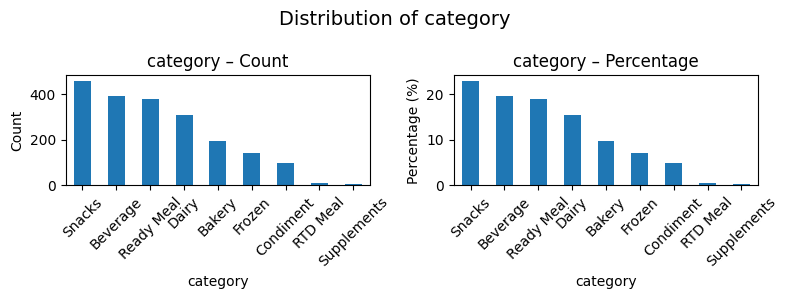

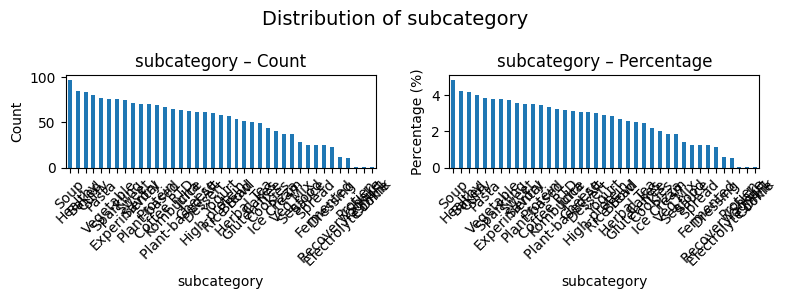

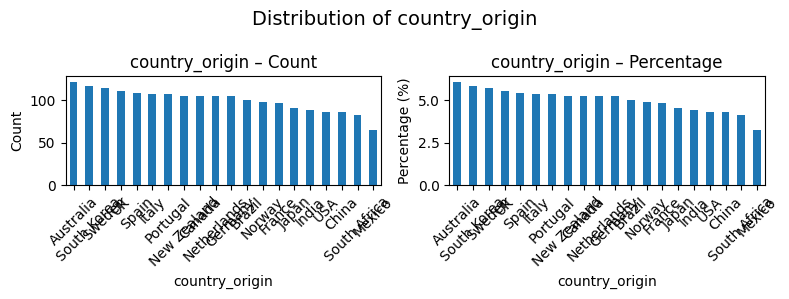

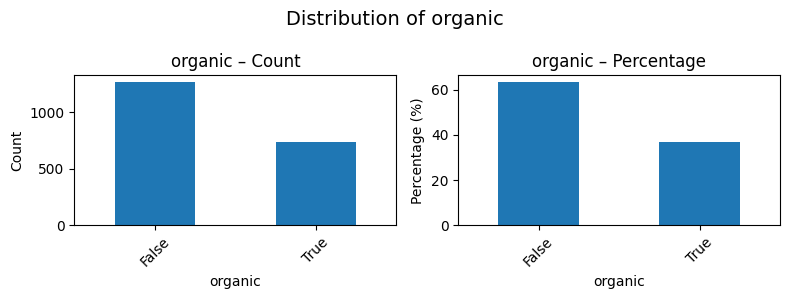

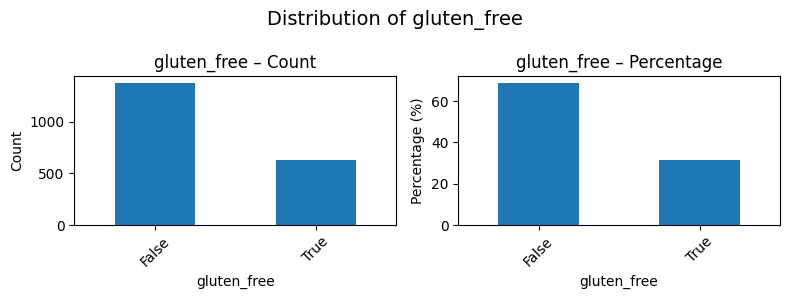

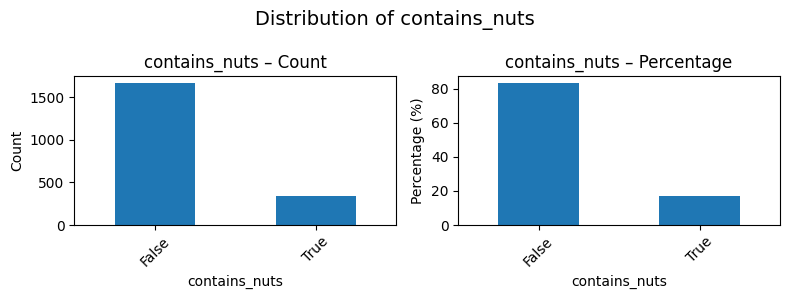

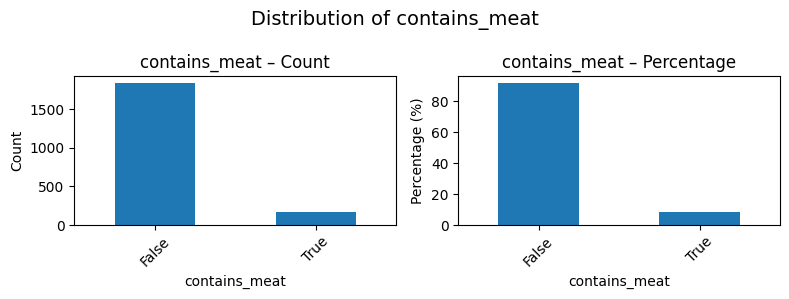

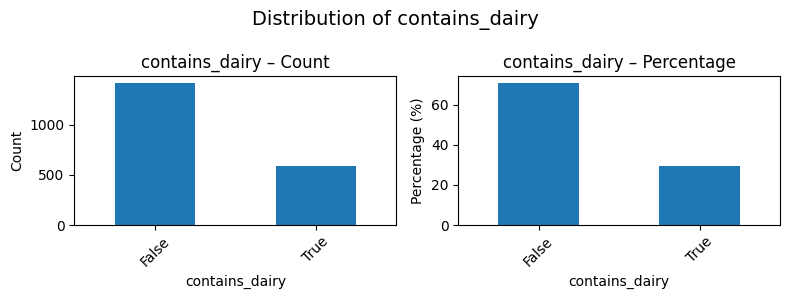

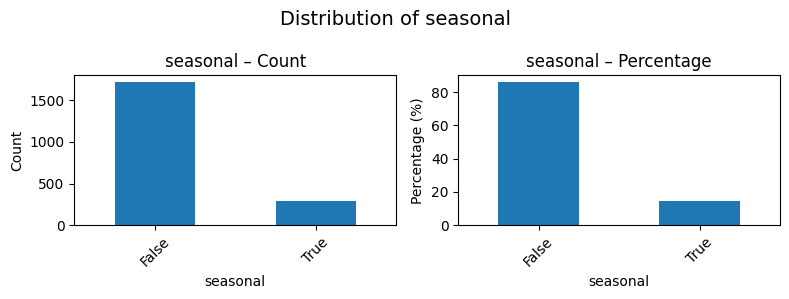

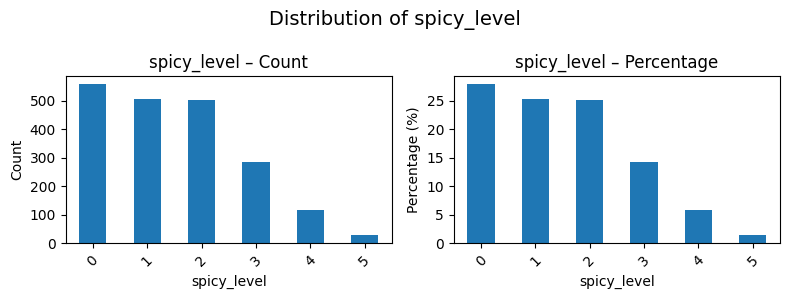

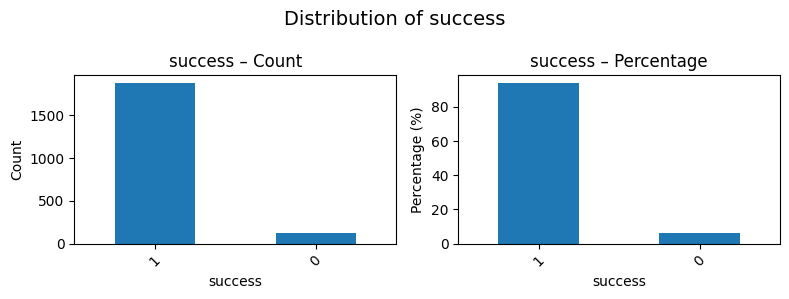

In [11]:
cat_var=["category","subcategory","country_origin", "organic", "gluten_free", "contains_nuts", "contains_meat", "contains_dairy", "seasonal", "spicy_level", "success"]
for i in cat_var:
    fig, axes = plt.subplots(1, 2, figsize=(8, 3))
    df[i].value_counts().plot(kind='bar', ax=axes[0])
    axes[0].set_title(f'{i} – Count')
    axes[0].set_xlabel(i)
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=45)
    
    (df[i].value_counts(normalize=True) * 100).plot(kind='bar', ax=axes[1])
    axes[1].set_title(f'{i} – Percentage')
    axes[1].set_xlabel(i)
    axes[1].set_ylabel('Percentage (%)')
    axes[1].tick_params(axis='x', rotation=45)

    plt.suptitle(f'Distribution of {i}', fontsize=14)
    plt.tight_layout()
    plt.show()

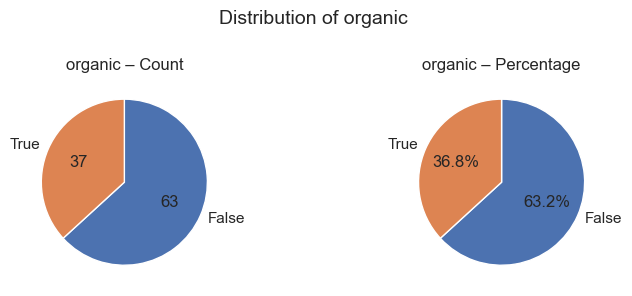

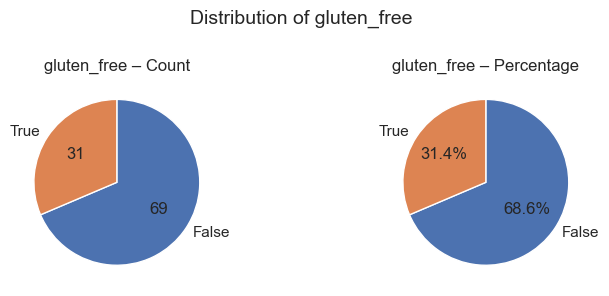

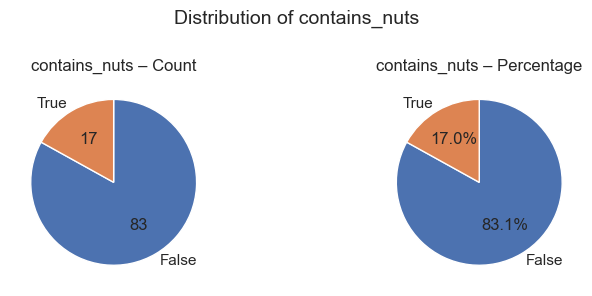

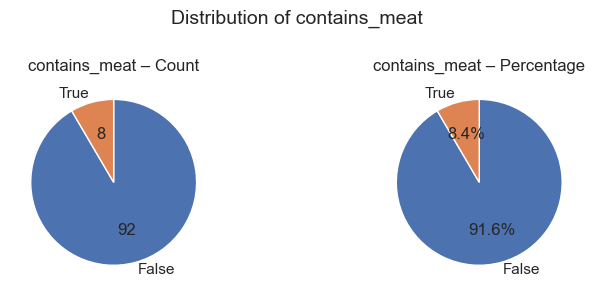

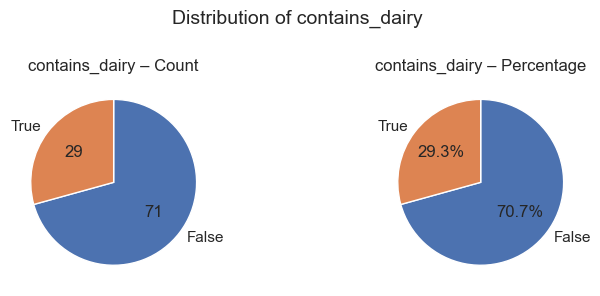

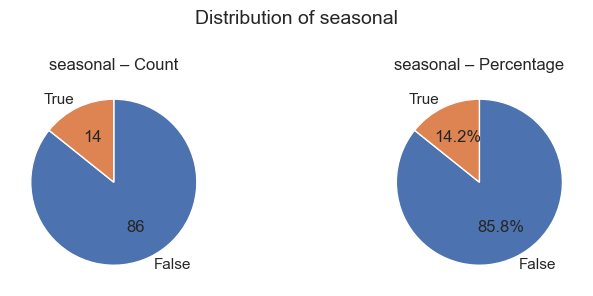

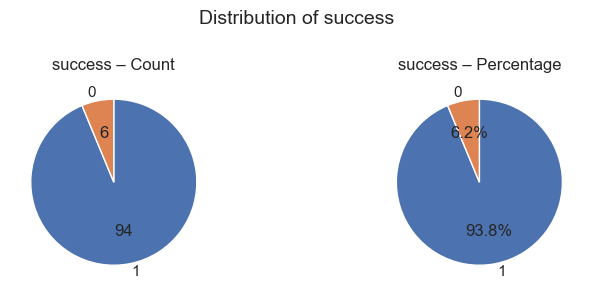

In [12]:
bool_var=["organic", "gluten_free", "contains_nuts", "contains_meat", "contains_dairy", "seasonal", "success"]

sns.set_theme(style="white")

for i in bool_var:
    counts = df[i].value_counts()
    percentages = df[i].value_counts(normalize=True) * 100
    labels = counts.index.astype(str)
    fig, axes = plt.subplots(1, 2, figsize=(8, 3))

    # Count pie
    axes[0].pie(counts, labels=labels, autopct='%1.0f', startangle=90, counterclock=False)
    axes[0].set_title(f'{i} – Count')

    # Percentage pie
    axes[1].pie(percentages,labels=labels, autopct='%1.1f%%', startangle=90, counterclock=False)
    axes[1].set_title(f'{i} – Percentage')
    plt.suptitle(f'Distribution of {i}', fontsize=14)
    plt.tight_layout()
    plt.show()


##### **Exploring the numerical variables**

In [13]:
df.describe()

,calories,fat_g,sugar_g,protein_g,fiber_g,sodium_mg,spicy_level,color_intensity,aroma_intensity,sweetness,...,brand_trust,packaging_appeal,eco_score,shelf_life_days,distribution_channels_count,review_count_prelaunch,allergy_warnings_count,marketing_spend_k,overall_appreciation,success
count,2000.000000,2000.000000,2000.000000,1929.000000,1937.000000,2000.000000,2000.000000,2000.000000,1930.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,202.360000,6.845400,9.761500,9.354743,2.378782,220.665500,1.496500,4.812650,5.478860,4.609800,...,6.389800,6.302650,69.400000,48.160500,3.699500,11.638000,1.233000,111883.200000,7.092942,0.937500
std,98.161006,3.561401,3.754188,5.429603,1.683788,259.859069,1.278204,2.086234,1.961022,2.681261,...,1.835568,1.978273,13.821632,22.141022,1.335699,11.425552,0.801269,25829.243556,1.784600,0.242122
min,9.000000,0.200000,0.500000,0.400000,0.100000,8.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,20.000000,3.000000,1.000000,0.000000,0.000000,34200.000000,0.548065,0.000000
25%,130.750000,3.875000,6.800000,5.600000,0.900000,101.000000,0.000000,3.300000,4.200000,2.500000,...,5.175000,4.900000,60.000000,33.000000,3.000000,5.000000,1.000000,94775.000000,5.982634,1.000000
50%,187.000000,6.900000,9.700000,7.300000,2.200000,165.000000,1.000000,4.800000,5.500000,4.500000,...,6.400000,6.400000,69.000000,55.000000,4.000000,8.000000,1.000000,111600.000000,7.320900,1.000000
75%,261.000000,9.300000,12.300000,13.200000,3.400000,277.000000,2.000000,6.200000,6.800000,6.700000,...,7.600000,7.700000,79.000000,64.000000,5.000000,15.000000,2.000000,128525.000000,8.402952,1.000000
max,520.000000,16.900000,24.000000,25.900000,8.000000,5520.000000,5.000000,10.000000,10.000000,10.000000,...,10.000000,10.000000,100.000000,89.000000,8.000000,124.000000,4.000000,196100.000000,10.000000,1.000000


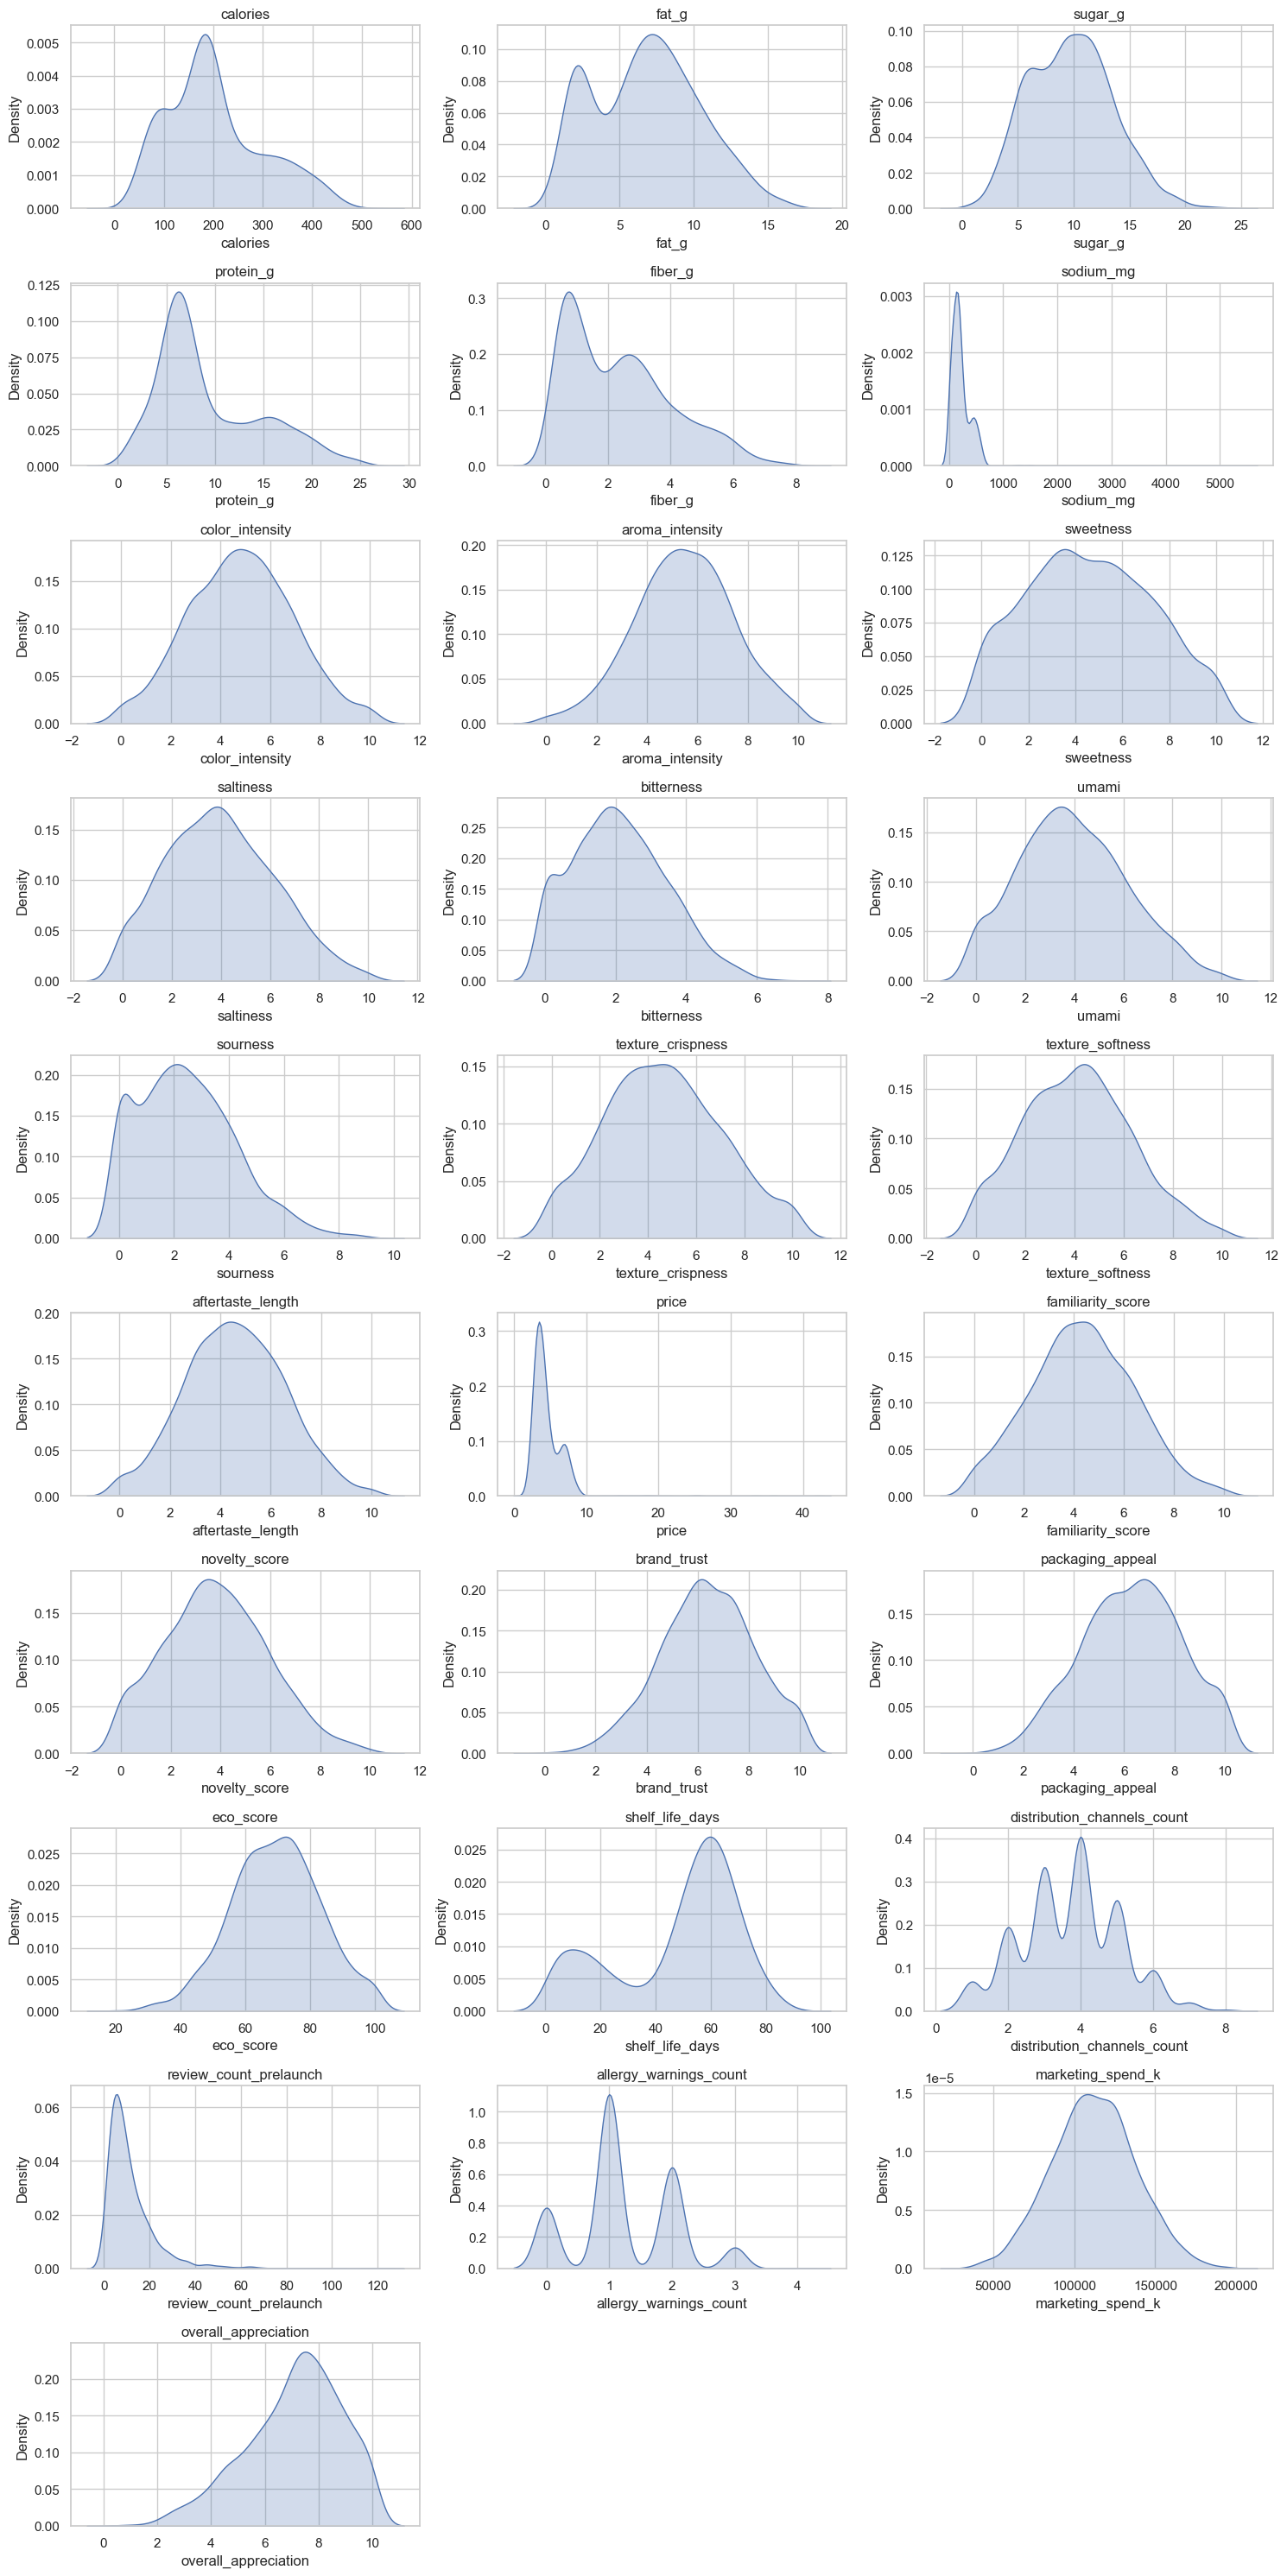

In [14]:
# Density plots

import math

sns.set_theme(style="whitegrid")

num_var = [i for i in df.columns if i not in cat_var]
n_cols = 3 
n_rows = math.ceil(len(num_var) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 3*n_rows))
axes = axes.flatten()
for ax, col in zip (axes, num_var):
    sns.kdeplot(data=df, x=col, ax=ax, fill=True)
    ax.set_title(col)
    ax.set_ylabel("Density")

# Remove empty subplots
for ax in axes[len(num_var):]:
    ax.remove()

plt.tight_layout()
plt.show()

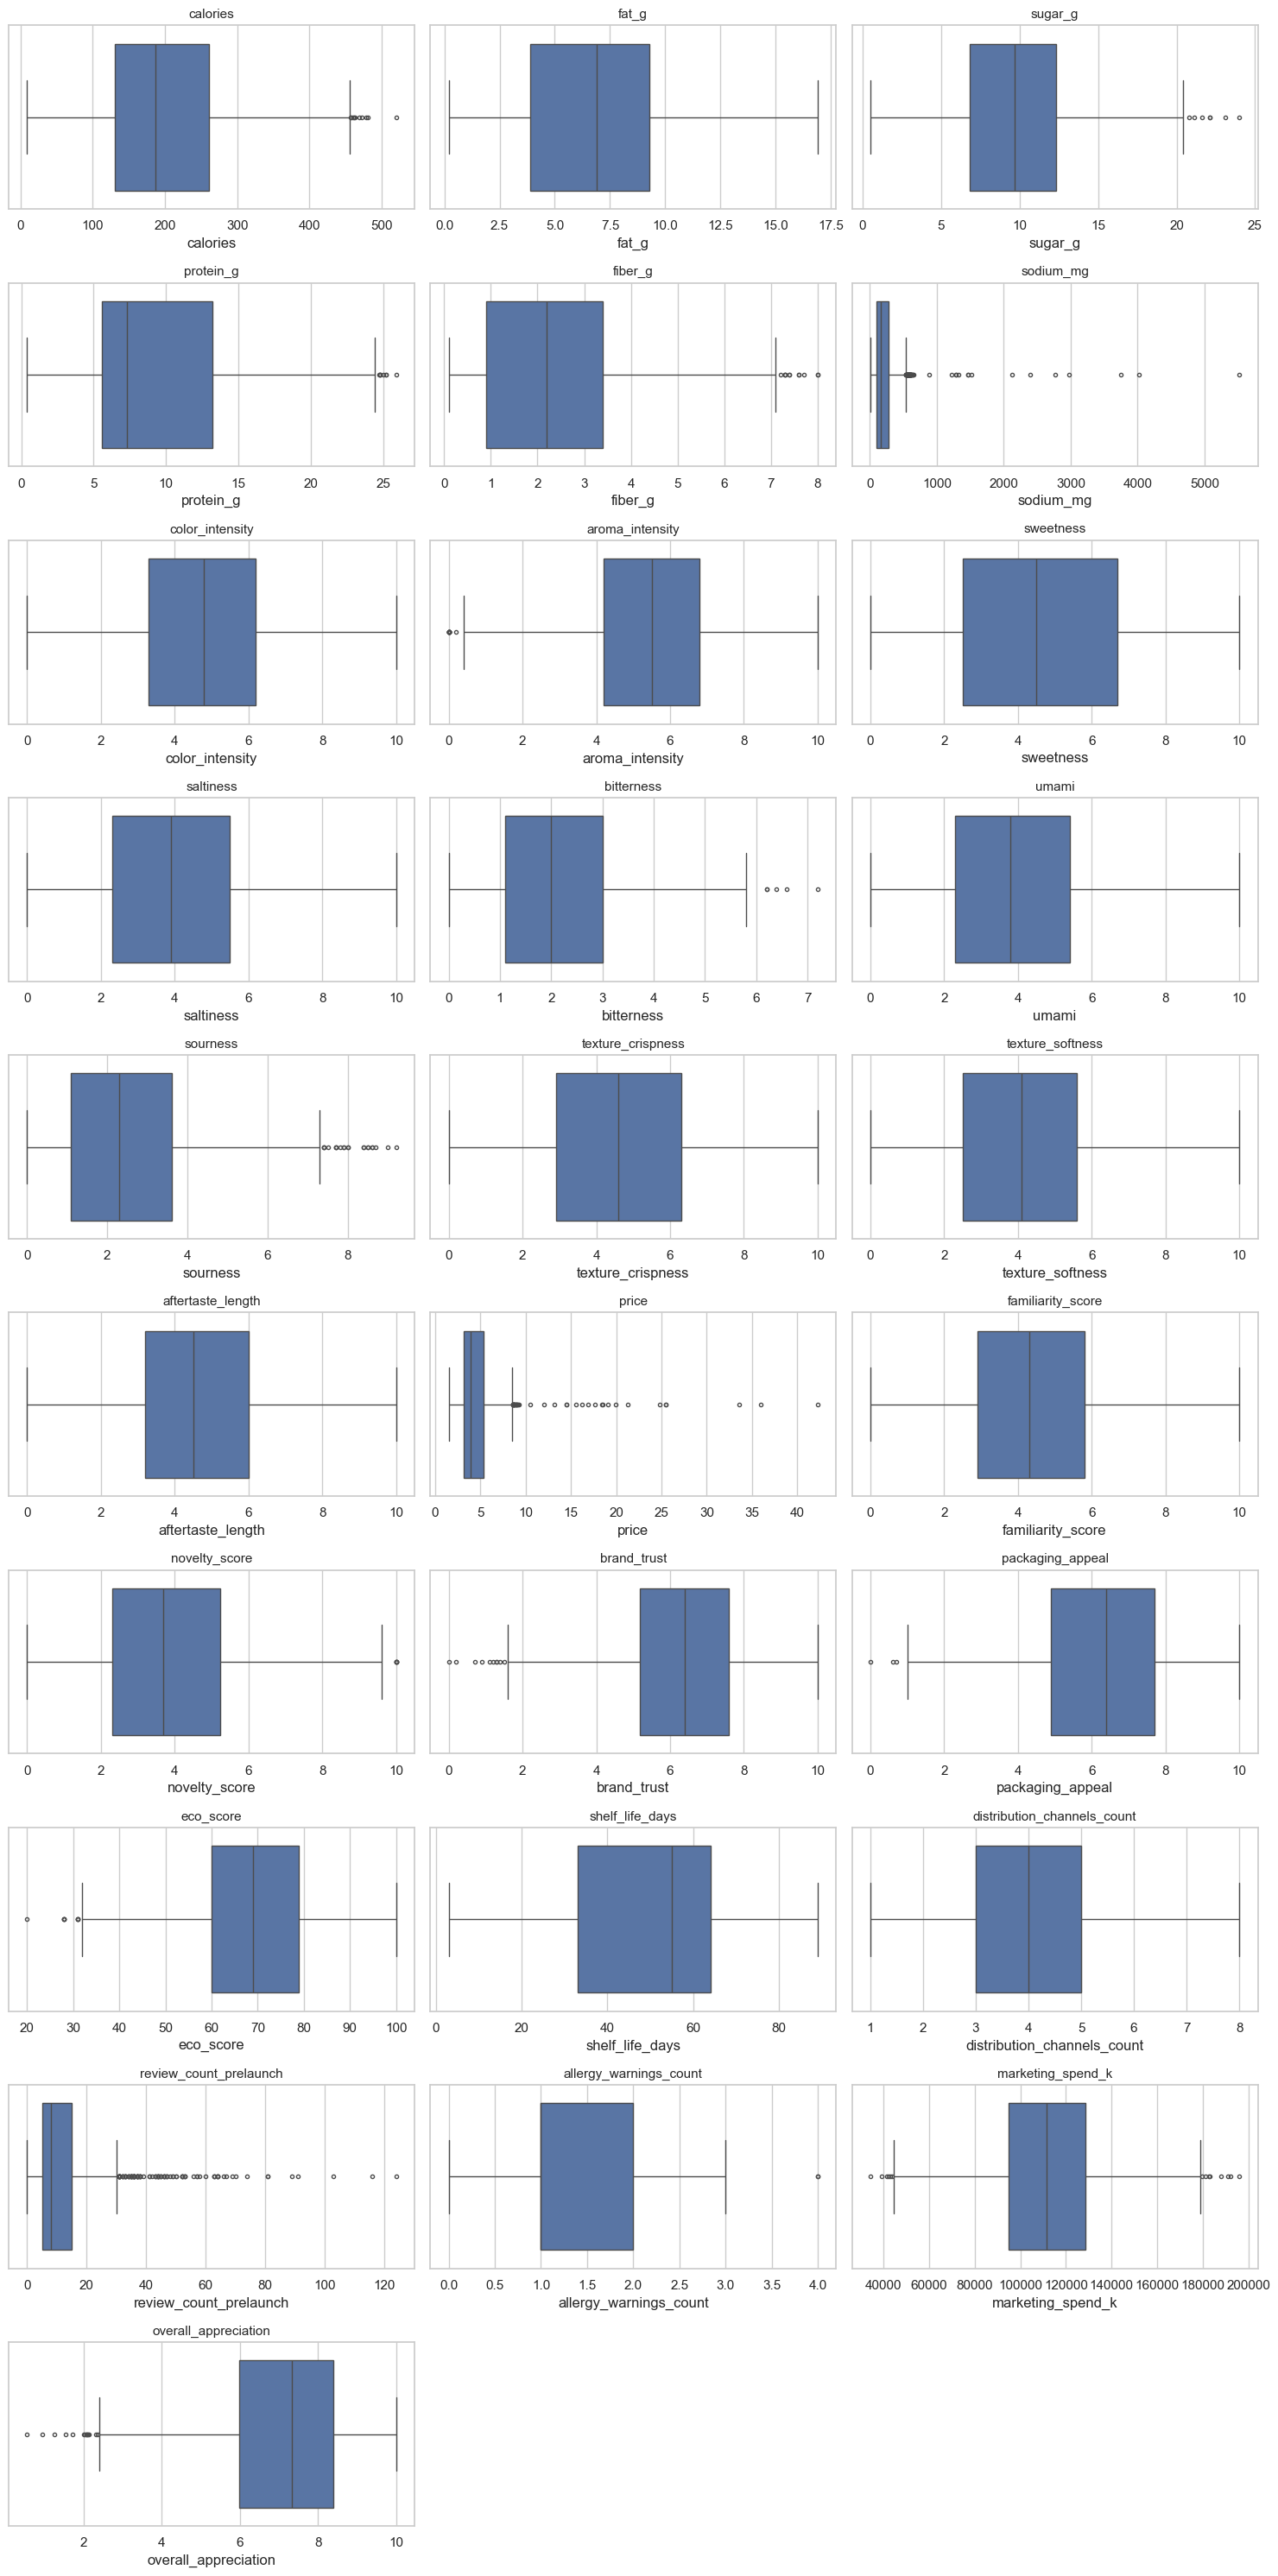

In [16]:
# Box plots

sns.set_theme(style="whitegrid")

num_var = [i for i in df.columns if i not in cat_var]
n_cols = 3
n_rows = math.ceil(len(num_var) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 3*n_rows))
axes = axes.flatten()

for ax, col in zip(axes, num_var):
    sns.boxplot(data=df, x=col, ax=ax, color="#4C72B0", fliersize=3, linewidth=1)
    ax.set_title(col, fontsize=11)

# Remove unused subplots
for ax in axes[len(num_var):]:
    ax.remove()

plt.tight_layout()
plt.show()

#### **Data preparation**

In [18]:
training_set = df.iloc[:1600]          # first 1600 rows
validation_set = df.iloc[1600:1800]    # next 200 rows
test_set = df.iloc[1800:2000]          #final 200 rows

##### **Create a pipeline for preprocessing**

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

In [20]:
#predictive variables for the training, validation and test sets
X = df.drop(columns= ["overall_appreciation", "success"])
X_train = training_set.drop(columns= ["overall_appreciation", "success"]) 
X_val = validation_set.drop(columns= ["overall_appreciation", "success"])  
X_test = test_set.drop(columns= ["overall_appreciation", "success"])

#target variables success and appreciation for the training, validation and test sets
y_success_train = training_set["success"]
y_appreciation_train = training_set["overall_appreciation"]

y_success_val = validation_set["success"]
y_appreciation_val = validation_set["overall_appreciation"]

y_success_test = test_set["success"]
y_appreciation_test = test_set["overall_appreciation"]

#identifying data types in each column
num_var = X.select_dtypes(include=["int64","float64"]).columns
cat_var = X.select_dtypes(include=["object"]).columns
ord_var = ["spicy_level"]
bool_var = X.select_dtypes(include=["bool"]).columns

#replacing missing values by median and scaling the numeric variables
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

#replacing missing values by mode (que não existe no nosso caso) and apply one hot encode on the categorical variables
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

#replacing missing values by mode (que não existe no nosso caso) and scale the ordinal variable
ord_pipeline = ordinal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("scaler", StandardScaler())
])

#run the preprocessing of the data, leave bool unchanged
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_var),
    ("cat", cat_pipeline, cat_var),
    ("ord", ord_pipeline, ord_var),
    ("bool", "passthrough", bool_var)
])


##### **Preprocessing fit and transformation**

In [21]:
#preprocessing fit and transformation
preprocessor.fit(X_train)
X_train_prep = preprocessor.transform(X_train)
X_val_prep = preprocessor.transform(X_val)
X_test_prep = preprocessor.transform(X_test)

###### **Back into dataframe**

In [22]:
feature_names = preprocessor.get_feature_names_out()
X_train_prep_df = pd.DataFrame(X_train_prep, columns=feature_names, index=X_train.index)
X_val_prep_df   = pd.DataFrame(X_val_prep, columns=feature_names, index=X_val.index)
X_test_prep_df  = pd.DataFrame(X_test_prep, columns=feature_names, index=X_test.index)

In [23]:
X_train_prep.shape

(1600, 98)

In [24]:
X_val_prep.shape

(200, 98)

In [25]:
X_test_prep.shape

(200, 98)

##### **Using smote for the unbalanced target success**

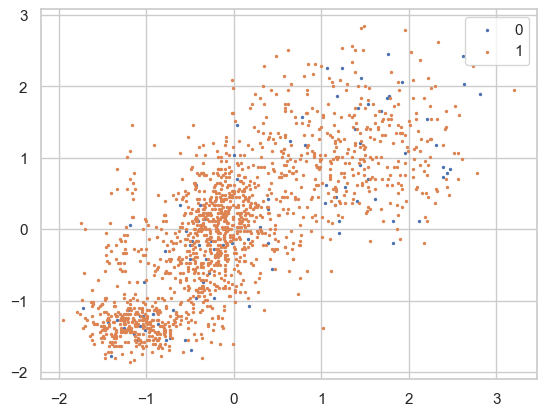

Original class distribution:
 success
1    1505
0      95
Name: count, dtype: int64


In [26]:
#scatter plot unbalanced data
from collections import Counter
from matplotlib import pyplot

counter = Counter(y_success_train)
for label in counter.keys():
    row_ix = y_success_train[y_success_train == label].index
    plt.scatter(
        X_train_prep_df.iloc[row_ix, 0],   # first feature
        X_train_prep_df.iloc[row_ix, 1],   # second feature
        label=str(label), s=2
    )

plt.legend()
plt.show()

#summarize class distribution
print("Original class distribution:\n", y_success_train.value_counts())

In [27]:
# transform the dataset
oversample = SMOTE()
X_train_balanced, y_success_train_balanced = oversample.fit_resample(X_train_prep_df, y_success_train)

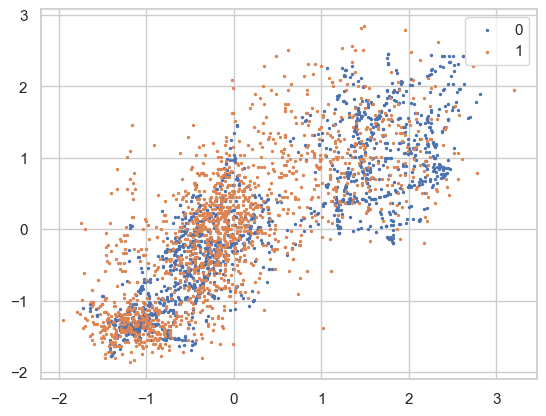

Balanced class distribution:
 success
0    1505
1    1505
Name: count, dtype: int64


In [28]:
#scatter plot balanced data
counter = Counter(y_success_train_balanced)
for label in counter.keys():
    row_ix = y_success_train_balanced[y_success_train_balanced == label].index
    plt.scatter(
        X_train_balanced.iloc[row_ix, 0],   # first feature
        X_train_balanced.iloc[row_ix, 1],   # second feature
        label=str(label), s=2
    )

plt.legend()
plt.show()

# summarize the new class distribution
print("Balanced class distribution:\n", pd.Series(y_success_train_balanced).value_counts())

##### **Selecting the best features**

In [29]:
#target success... 
from sklearn.feature_selection import SelectKBest, chi2, f_classif, mutual_info_classif

# ... vs categorical features (chi2)
X_cat = X_train_balanced.filter(regex='^(cat|ord|bool)')
X_chi = X_cat.copy()
min_vals = X_chi.min(axis=0)
X_chi = X_chi - min_vals
selector_chi2 = SelectKBest(score_func=chi2, k='all')
chi2_scores = selector_chi2.fit(X_chi, y_success_train_balanced).scores_

# ... vs numerical features (mutual info)
X_num = X_train_balanced.filter(regex='^num')
selector_mi = SelectKBest(score_func=mutual_info_classif, k='all')
mi_scores = selector_mi.fit(X_num, y_success_train_balanced).scores_

# Assuming X_train_balanced is a pandas DataFrame
feature_names_cat = X_cat.columns
feature_names_num = X_num.columns

# Chi-square scores
chi2_results = pd.DataFrame({'Feature': feature_names_cat, 'Chi2_Score': chi2_scores}).sort_values(by='Chi2_Score', ascending=False)

# Mutual information scores
mi_results = pd.DataFrame({'Feature': feature_names_num, 'Mutual_Info_Score': mi_scores}).sort_values(by='Mutual_Info_Score', ascending=False)

# Display top features
print("Top features by Chi2:")
with pd.option_context('display.max_rows', None):
    display(chi2_results)

print("\nTop features by Mutual Information:")
with pd.option_context('display.max_rows', None):
    display(mi_results)

Top features by Chi2:


,Feature,Chi2_Score
5,cat__category_Ready Meal,120.430394
62,cat__country_origin_USA,66.000000
38,cat__subcategory_Sweet,58.000000
13,cat__subcategory_Curry,52.613469
56,cat__country_origin_Portugal,51.037074
6,cat__category_Snacks,45.205545
9,cat__subcategory_Cakes,39.000000
53,cat__country_origin_Netherlands,36.959410
25,cat__subcategory_Pasta,36.531337
57,cat__country_origin_South Africa,30.751950



Top features by Mutual Information:


,Feature,Mutual_Info_Score
22,num__eco_score,0.482528
11,num__bitterness,0.467677
25,num__review_count_prelaunch,0.456700
18,num__familiarity_score,0.455959
21,num__packaging_appeal,0.454482
20,num__brand_trust,0.453711
16,num__aftertaste_length,0.451733
13,num__sourness,0.446102
15,num__texture_softness,0.446052
4,num__fiber_g,0.445964


In [30]:
#Discarding features based on the p-value for chi2
chi2_scores, p_values = chi2(X_chi, y_success_train_balanced)
chi2_pvalues_df = pd.DataFrame({'Feature': X_chi.columns, 'Chi2_Score': chi2_scores, 'P_Value': p_values}).sort_values(by='P_Value')

print("Top features by Chi2:")
with pd.option_context('display.max_rows', None):
    display(chi2_pvalues_df)
    
#discarding features based on mutual info: discard when MI <0.001

Top features by Chi2:


,Feature,Chi2_Score,P_Value
5,cat__category_Ready Meal,120.430394,5.092253e-28
62,cat__country_origin_USA,66.000000,4.509230e-16
38,cat__subcategory_Sweet,58.000000,2.621178e-14
13,cat__subcategory_Curry,52.613469,4.060946e-13
56,cat__country_origin_Portugal,51.037074,9.063777e-13
6,cat__category_Snacks,45.205545,1.774021e-11
9,cat__subcategory_Cakes,39.000000,4.238055e-10
53,cat__country_origin_Netherlands,36.959410,1.206142e-09
25,cat__subcategory_Pasta,36.531337,1.502315e-09
57,cat__country_origin_South Africa,30.751950,2.932091e-08


In [31]:
# target overall_appreciation...

from sklearn.feature_selection import f_regression, mutual_info_regression

# ... vs numerical features (f_regression)
X_num2 = X_train_prep_df.filter(regex='^num')
selector_fr = SelectKBest(score_func=f_regression, k='all')
f_scores = selector_fr.fit(X_num2, y_appreciation_train).scores_

# ... vs categorical features (mutual info regression)
X_cat2 = X_train_prep_df.filter(regex='^(cat|ord|bool)')
selector_mir = SelectKBest(score_func=mutual_info_regression, k='all')
mi_reg_scores = selector_mir.fit(X_cat2, y_appreciation_train).scores_

feature_names_cat2 = X_cat2.columns
feature_names_num2 = X_num2.columns

# f_regression scores
f_reg_results = pd.DataFrame({
    'Feature': feature_names_num2,
    'f_score': f_scores
}).sort_values(by='f_score', ascending=False)

# Mutual information scores
mi_reg_results = pd.DataFrame({'Feature': feature_names_cat2, 'Mutual_Reg_Score': mi_reg_scores}).sort_values(by='Mutual_Reg_Score', ascending=False)

# Display top features
print("Top features by F-regression:")
with pd.option_context('display.max_rows', None):
    display(f_reg_results)

print("\nTop features by MI Regression:")
with pd.option_context('display.max_rows', None):
    display(mi_reg_results)

Top features by F-regression:


,Feature,f_score
0,num__calories,647.047659
4,num__fiber_g,486.061072
3,num__protein_g,456.316943
17,num__price,371.546403
1,num__fat_g,334.873114
10,num__saltiness,326.514980
5,num__sodium_mg,299.609538
2,num__sugar_g,273.134029
9,num__sweetness,236.739235
12,num__umami,116.420369



Top features by MI Regression:


,Feature,Mutual_Reg_Score
5,cat__category_Ready Meal,0.239838
35,cat__subcategory_Soup,0.054477
6,cat__category_Snacks,0.046831
13,cat__subcategory_Curry,0.040151
1,cat__category_Beverage,0.037588
25,cat__subcategory_Pasta,0.033685
31,cat__subcategory_Rice Bowl,0.031937
27,cat__subcategory_Plant-based,0.030248
3,cat__category_Dairy,0.029858
67,bool__contains_meat,0.025791


In [32]:
#discarding features based on f-regression: <0.5
#discarding features based on MI-regression: <0.01

We decided to maintain all features for both targets, but based on the pearson correlation, we were able to detect redundancy in some features: calories, fat, fiber and protein. For that reason, we chose to maintain only the calories feature:

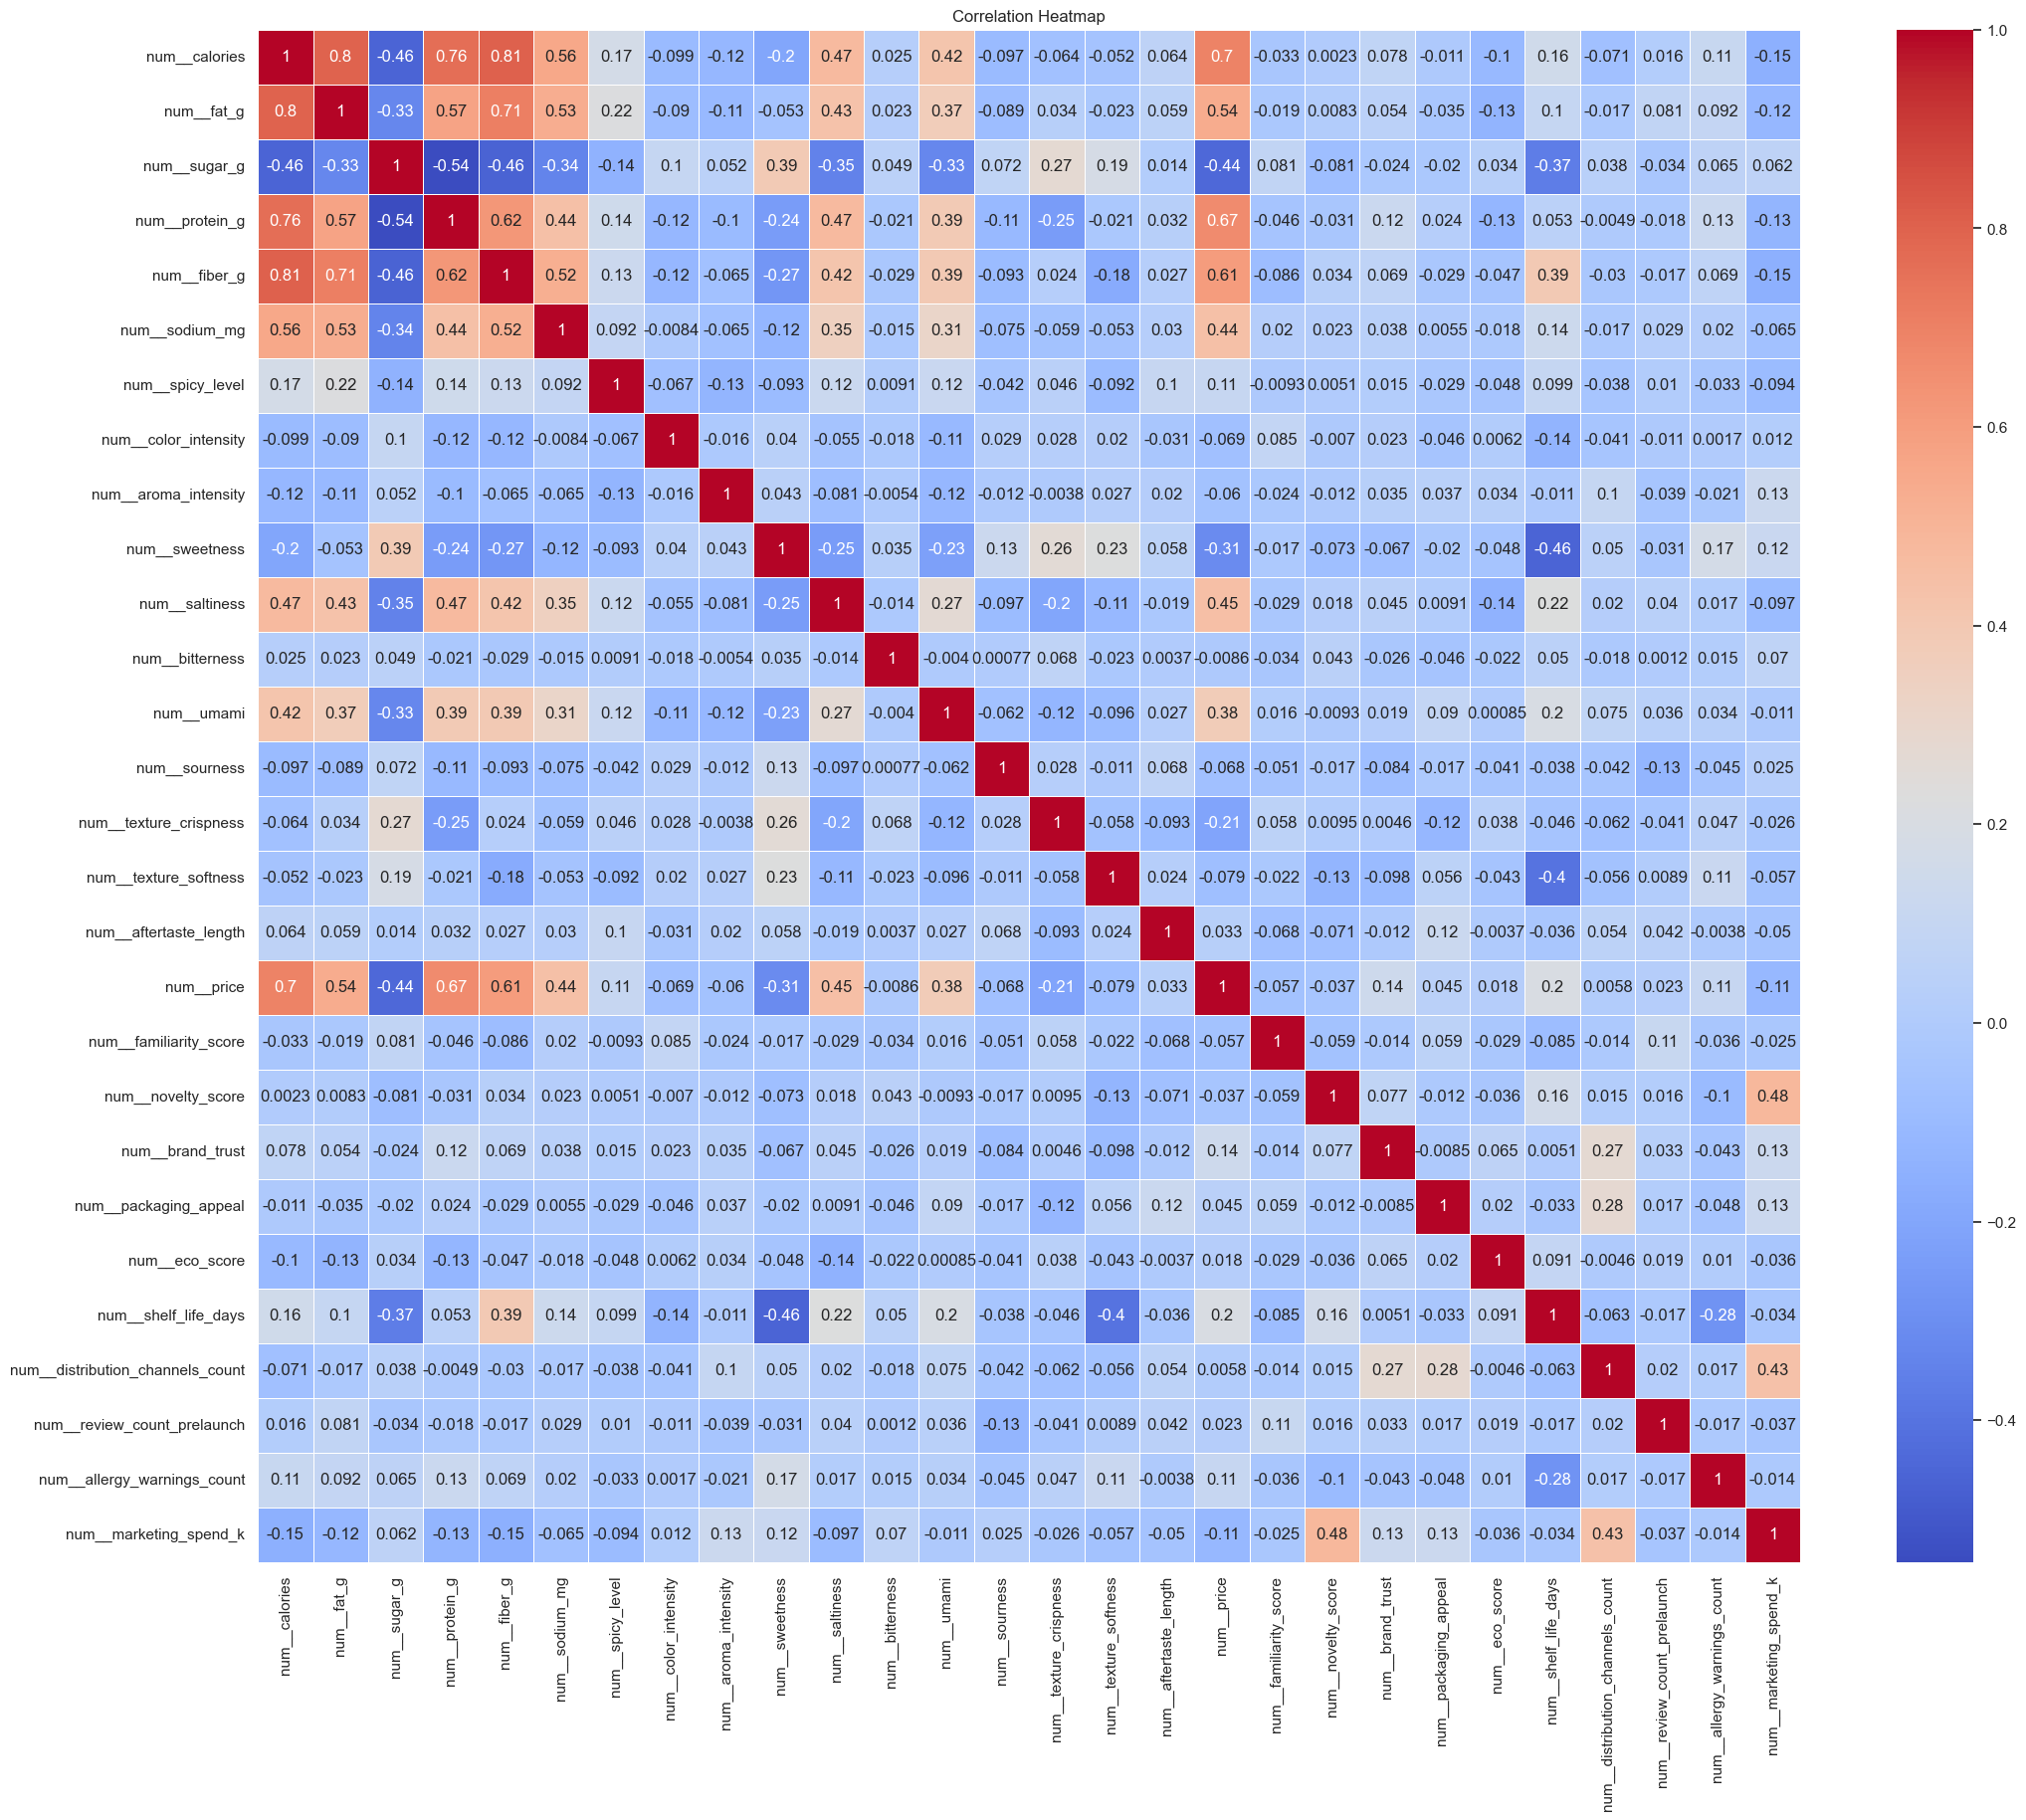

In [33]:
plt.figure(figsize=(25,20))
sns.heatmap(X_num.corr(), annot=True,  cmap='coolwarm', linewidths=0.5).set_title("Correlation Heatmap")
plt.show()

In [34]:
#dropping fat, protein, and fiber from the balanced and unbalanced datasets
col = ['num__fat_g', 'num__fiber_g', 'num__protein_g']

X_train_model = X_train_prep_df.drop(columns=col)
X_val_model = X_val_prep_df.drop(columns=col)
X_test_model = X_test_prep_df.drop(columns=col)
X_train_balanced_model = X_train_balanced.drop(columns=col)

#### **Modeling**

##### **Running the ML models on the success variable**

##### Training with the balanced data

In [35]:
from sklearn.model_selection import cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Define models + hyperparameters
models = {
    "KNN": KNeighborsClassifier(n_neighbors=7, p=2),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(max_depth=10, min_samples_split=10, min_samples_leaf=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=700, max_depth=50, random_state=42),
    "SVM": SVC(kernel="linear", probability=True, random_state=42),
    "Neural Net": MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, early_stopping=True, random_state=42)
}

# Metrics to compute during CV
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

cv_results = []

#Cross-validation on training set
for name, model in models.items():
    pipe = Pipeline([("classifier", model)])
    
    cv_scores = cross_validate(pipe, X_train_balanced_model, y_success_train_balanced, cv=5, scoring=scoring)
    
    cv_results.append({
        "Model": name,
        "CV Accuracy": np.mean(cv_scores["test_accuracy"]),
        "CV Precision": np.mean(cv_scores["test_precision"]),
        "CV Recall": np.mean(cv_scores["test_recall"]),
        "CV F1": np.mean(cv_scores["test_f1"]),
        "CV ROC-AUC": np.mean(cv_scores["test_roc_auc"])
    })

cv_results_df = pd.DataFrame(cv_results)
print("Cross-validation results:\n", cv_results_df)

#Validation set evaluation
val_results = []

for name, model in models.items():
    pipe = Pipeline([("classifier", model)])
    
    pipe.fit(X_train_balanced_model, y_success_train_balanced)  # fit on full training set
    val_preds = pipe.predict(X_val_model)
    val_probs = pipe.predict_proba(X_val_model)[:,1] if hasattr(pipe, "predict_proba") else None
    
    val_results.append({
        "Model": name,
        "Val Accuracy": accuracy_score(y_success_val, val_preds),
        "Val Precision": precision_score(y_success_val, val_preds),
        "Val Recall": recall_score(y_success_val, val_preds),
        "Val F1": f1_score(y_success_val, val_preds),
        "Val ROC-AUC": roc_auc_score(y_success_val, val_probs) if val_probs is not None else np.nan
    })

val_results_df = pd.DataFrame(val_results)
print("Validation results:\n", val_results_df)

# Choose the best model
best_model_name = val_results_df.loc[val_results_df["Val ROC-AUC"].idxmax(), "Model"]
print(f"Best model selected: {best_model_name}")

best_model = models[best_model_name]
best_pipe = Pipeline([("classifier", best_model)])

best_pipe.fit(X_train_balanced_model, y_success_train_balanced)

test_preds = best_pipe.predict(X_test_model)
test_probs = best_pipe.predict_proba(X_test_model)[:,1]

print("Final Test Accuracy:", accuracy_score(y_success_test, test_preds))
print("Final Test Precision:", precision_score(y_success_test, test_preds))
print("Final Test Recall:", recall_score(y_success_test, test_preds))
print("Final Test F1:", f1_score(y_success_test, test_preds))
print("Final Test ROC-AUC:", roc_auc_score(y_success_test, test_probs))

Cross-validation results:
            Model  CV Accuracy  CV Precision  CV Recall     CV F1  CV ROC-AUC
0            KNN     0.691362      1.000000   0.382724  0.553481    0.908099
1    Naive Bayes     0.627907      0.975934   0.262458  0.412077    0.812746
2  Decision Tree     0.893023      0.881801   0.918937  0.896791    0.942879
3  Random Forest     0.982724      0.973410   0.996013  0.983804    0.998981
4            SVM     0.748505      0.810528   0.648505  0.720414    0.797709
5     Neural Net     0.956811      0.999270   0.914286  0.954839    0.994594
Validation results:
            Model  Val Accuracy  Val Precision  Val Recall    Val F1  \
0            KNN         0.420       0.902439    0.406593  0.560606   
1    Naive Bayes         0.350       0.964286    0.296703  0.453782   
2  Decision Tree         0.890       0.912371    0.972527  0.941489   
3  Random Forest         0.910       0.910000    1.000000  0.952880   
4            SVM         0.695       0.935252    0.714286 

##### ML models ranked by ROC-AUC for the validation data set 

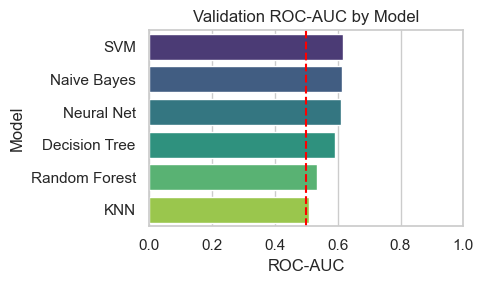

In [36]:
plot_df = val_results_df.sort_values("Val ROC-AUC", ascending=False)
plt.figure(figsize=(5, 3)) 
sns.barplot( data=plot_df, x="Val ROC-AUC", y="Model", hue='Model', palette="viridis" )
plt.title("Validation ROC-AUC by Model") 
plt.xlabel("ROC-AUC") 
plt.ylabel("Model") 
plt.xlim(0, 1)
plt.axvline(x=0.5, color='red', linestyle='--')
plt.tight_layout() 
plt.show()

##### Top features using ROC-AUC for the validation set as scoring

C:\Users\raque\AppData\Local\Temp\ipykernel_16808\3155922046.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot( data=top_15features, x="Importance", y="Feature", palette="viridis" )


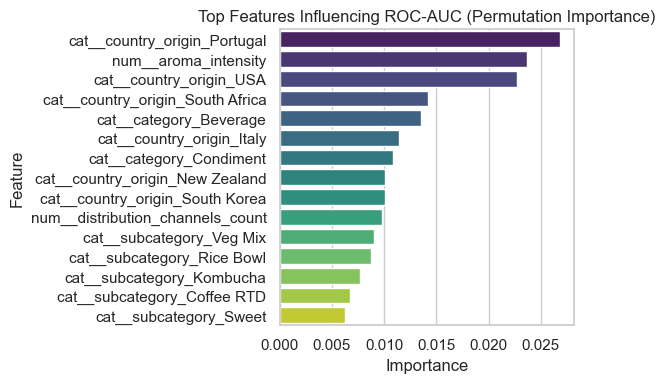

In [37]:
from sklearn.inspection import permutation_importance

# Compute permutation importance using ROC-AUC as scoring 
perm = permutation_importance(best_pipe, X_val_model, y_success_val, scoring="roc_auc", n_repeats=20, random_state=42)

# Build DataFrame 
feature_importance_df = pd.DataFrame({"Feature": X_val_model.columns, "Importance": perm.importances_mean, "Std": perm.importances_std }).sort_values("Importance", ascending=False)

top_15features = feature_importance_df.head(15)
plt.figure(figsize=(6, 4))
sns.barplot( data=top_15features, x="Importance", y="Feature", hue='Feature', palette="viridis" )
plt.title("Top Features Influencing ROC-AUC")
plt.xlabel("Importance") 
plt.ylabel("Feature") 
plt.tight_layout() 
plt.show()

##### Confusion Matrix for the ML trained with the balanced data

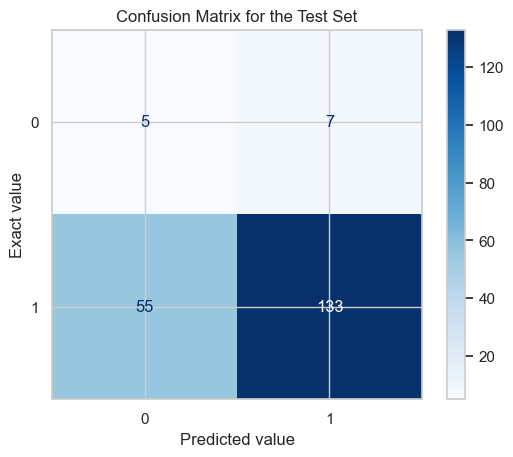

In [38]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute confusion matrix
cm = confusion_matrix(y_success_test, test_preds)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_pipe.classes_)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix for the Test Set")
plt.xlabel("Predicted value") 
plt.ylabel("Exact value") 
plt.show()

##### Training with the unbalanced data + confusion matrix

Final Test Accuracy: 0.69
Final Test Precision: 0.95
Final Test Recall: 0.7074468085106383
Final Test F1: 0.8109756097560976
Final Test ROC-AUC: 0.6520390070921986


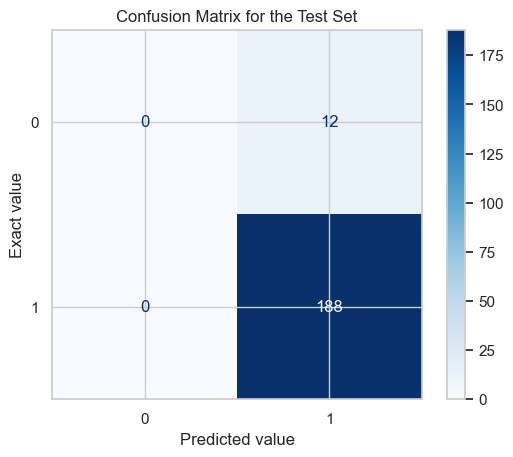

In [39]:
best_pipe.fit(X_train_model, y_success_train)

test_preds_unbalanced = best_pipe.predict(X_test_model)
test_probs_unbalanced = best_pipe.predict_proba(X_test_model)[:,1]

print("Final Test Accuracy:", accuracy_score(y_success_test, test_preds))
print("Final Test Precision:", precision_score(y_success_test, test_preds))
print("Final Test Recall:", recall_score(y_success_test, test_preds))
print("Final Test F1:", f1_score(y_success_test, test_preds))
print("Final Test ROC-AUC:", roc_auc_score(y_success_test, test_probs))

# Compute confusion matrix
cm = confusion_matrix(y_success_test, test_preds_unbalanced)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_pipe.classes_)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix for the Test Set")
plt.xlabel("Predicted value") 
plt.ylabel("Exact value")  
plt.show()

##### **Running the ML models in the overall_appreciation variable**

In [40]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Regression models
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import BayesianRidge, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

# Define regression models + hyperparameters
models_regression = {
    "KNN": KNeighborsRegressor(n_neighbors=5),
    "Bayesian Ridge": BayesianRidge(),
    "Ridge": Ridge(alpha=0.5, random_state=42),                                  
    "Lasso": Lasso(alpha=0.005, max_iter=5000, random_state=42),
    "Decision Tree": DecisionTreeRegressor(max_depth=8, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, random_state=42),
    "SVR": SVR(kernel="rbf", C=1.0, gamma="scale"),
    "Neural Net": MLPRegressor(hidden_layer_sizes=(100,), max_iter=2000, early_stopping=True, random_state=42)
}

# Metrics to compute during CV
scoring_regression = ["neg_mean_absolute_error", "neg_mean_squared_error", "r2"]

cv_results = []

# Cross-validation on training set
for name, model in models_regression.items():
    pipe = Pipeline([
        ("regressor", model)
    ])
    
    cv_scores = cross_validate(pipe, X_train_model, y_appreciation_train, cv=5, scoring=scoring_regression)
    
    cv_results.append({
        "Model": name,
        "CV MAE": -np.mean(cv_scores["test_neg_mean_absolute_error"]),
        "CV MSE": -np.mean(cv_scores["test_neg_mean_squared_error"]),
        "CV R2": np.mean(cv_scores["test_r2"])
    })

cv_results_df = pd.DataFrame(cv_results)
print("Cross-validation results:\n", cv_results_df)

# Validation
val_results = []
for name, model in models_regression.items():
    pipe = Pipeline([
        ("regressor", model)
    ])
    
    pipe.fit(X_train_model, y_appreciation_train)  # fit on full training set
    val_preds = pipe.predict(X_val_model)
    
    val_results.append({
        "Model": name,
        "Val MAE": mean_absolute_error(y_appreciation_val, val_preds),
        "Val MSE": mean_squared_error(y_appreciation_val, val_preds),
        "Val R2": r2_score(y_appreciation_val, val_preds)
    })

val_results_df = pd.DataFrame(val_results)
print("Validation results:\n", val_results_df)

# Choose the best model
best_model = Lasso(alpha=0.005, random_state=42)
best_pipe = Pipeline([
    ("regressor", best_model)
])
best_pipe.fit(X_train_model, y_appreciation_train)

# Final Test
test_preds = best_pipe.predict(X_test_model)

print("Final Test MAE:", mean_absolute_error(y_appreciation_test, test_preds))
print("Final Test MSE:", mean_squared_error(y_appreciation_test, test_preds))
print("Final Test R2:", r2_score(y_appreciation_test, test_preds))

Cross-validation results:
                Model    CV MAE    CV MSE     CV R2
0                KNN  0.994379  1.574143  0.500463
1     Bayesian Ridge  0.782540  0.982189  0.687427
2              Ridge  0.789721  0.999428  0.682077
3              Lasso  0.775719  0.963345  0.693279
4      Decision Tree  1.093071  1.932742  0.385147
5      Random Forest  0.831175  1.094976  0.651505
6  Gradient Boosting  0.794191  1.009944  0.678383
7                SVR  0.836533  1.115792  0.645551
8         Neural Net  0.908874  1.316816  0.581501
Validation results:
                Model   Val MAE   Val MSE    Val R2
0                KNN  1.025365  1.537366  0.543057
1     Bayesian Ridge  0.825250  1.013422  0.698786
2              Ridge  0.828226  1.014076  0.698592
3              Lasso  0.806671  0.980528  0.708563
4      Decision Tree  1.053115  1.719329  0.488973
5      Random Forest  0.913406  1.198462  0.643788
6  Gradient Boosting  0.874243  1.115207  0.668533
7                SVR  0.832018  1.

###### ML models ranked by R2 for the validation data set 

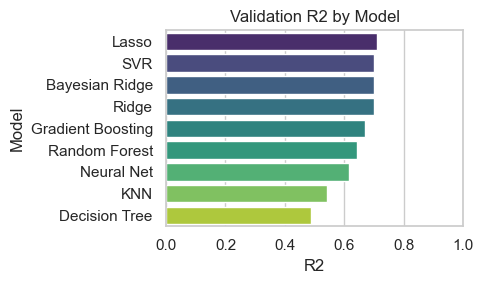

In [41]:
plot_df = val_results_df.sort_values("Val R2", ascending=False)
plt.figure(figsize=(5, 3)) 
sns.barplot( data=plot_df, x="Val R2", y="Model", hue='Model', palette="viridis" )
plt.title("Validation R2 by Model") 
plt.xlabel("R2") 
plt.ylabel("Model") 
plt.xlim(0, 1)
plt.tight_layout() 
plt.show()

##### Feature importance for the Lasso model

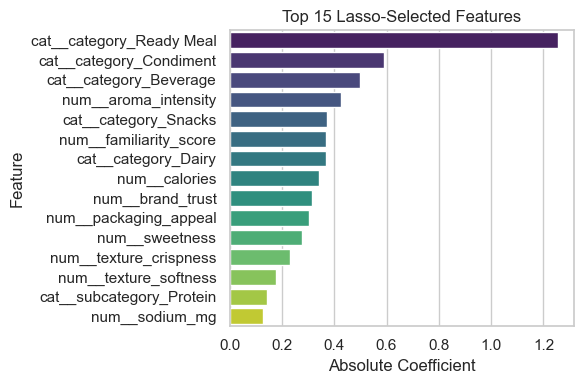

In [42]:
#Get feature names
if hasattr(X_train_model, "columns"):
    feature_names = X_train_model.columns
else:
    # If it came from a preprocessor / pipeline
    feature_names = preprocessor.get_feature_names_out()

#Extract coefficients from the trained Lasso model
lasso_model = best_pipe.named_steps["regressor"]
coefficients = lasso_model.coef_

#Create a DataFrame mapping features to coefficients
lasso_coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

#Identify selected features (non-zero coefficients)
lasso_selected = lasso_coef_df[lasso_coef_df["Coefficient"] != 0].copy()

#Rank features by absolute importance
lasso_selected["Abs_Coefficient"] = lasso_selected["Coefficient"].abs()
lasso_selected = lasso_selected.sort_values("Abs_Coefficient", ascending=False)
top15 = lasso_selected.head(15)
plt.figure(figsize=(6, 4))
sns.barplot( data=top15, x="Abs_Coefficient", y="Feature", hue= 'Feature', palette="viridis" )
plt.title("Top 15 Lasso-Selected Features")
plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

###### Predicted vs Actual Scatter Plot

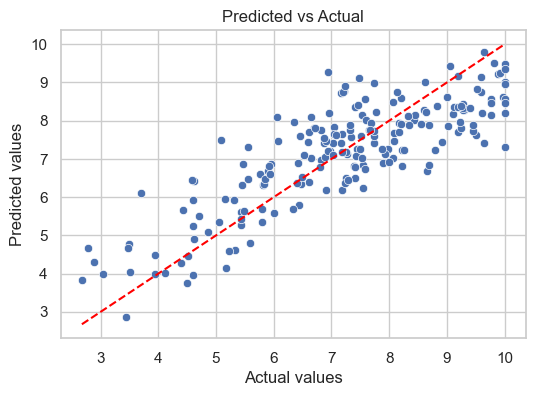

In [43]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=y_appreciation_test, y=test_preds)
plt.plot([y_appreciation_test.min(), y_appreciation_test.max()],
         [y_appreciation_test.min(), y_appreciation_test.max()],
         color="red", linestyle="--")
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title("Predicted vs Actual")
plt.show()

###### Residuals vs Actual scores

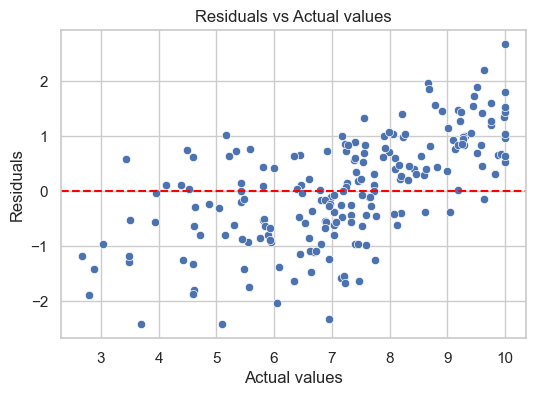

In [44]:
residuals = y_appreciation_test - test_preds

plt.figure(figsize=(6,4))
sns.scatterplot(x=y_appreciation_test, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Actual values")
plt.ylabel("Residuals")
plt.title("Residuals vs Actual values")
plt.show()

###### Distribution of Residuals

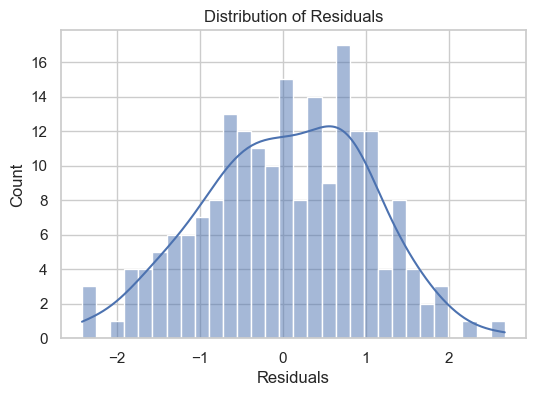

In [45]:
plt.figure(figsize=(6,4))
sns.histplot(residuals, bins=30, kde=True)
plt.xlabel("Residuals")
plt.title("Distribution of Residuals")
plt.show()

#### **Main Conclusions**

Regarding the overall appreciation target feature, several regression models were evaluated, including linear, ensemble-based, and non-linear approaches, using a structured workflow consisting of cross-validation, validation, and final testing on unseen data. Based on the model comparison, Lasso regression was identified as the best-performing and most suitable model for this business problem. With optimized hyperparameters (α = 0.005), Lasso consistently achieved the lowest mean absolute error and the highest explained variance (R²) across all evaluation stages. Its performance remained stable between cross-validation, validation, and test sets, indicating strong generalization and an appropriate balance between bias and variance. As a result, Lasso regression is recommended as the final model. From a business perspective, the final model explains approximately 69% of the variability in overall appreciation while maintaining a average prediction error of around 0.8 units. Furthermore, because Lasso regression performs automatic feature selection, it offers interpretable insights into which factors most strongly influence appreciation. These insights can be leveraged to prioritize resources, define strategies, and focus on the features that matter most to the business.

Several important lessons were learned throughout the overall appreciation analysis. Model complexity does not necessarily lead to better performance. In this case, regularized linear models outperformed more complex methods such as Random Forest and Neural Networks, indicating that the underlying relationships in the data are predominantly linear. While hyperparameter tuning improved model performance, further optimization would likely only result in small gains and could increase the risk of overfitting. Finally, the consistency of results across evaluation stages highlights the importance of robust model assessment practices, as they ensure that performance improvements are genuine and not artifacts of a particular data split.